In [57]:
import numpy as np
import mne
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.gridspec as gridspec
import matplotlib.transforms
#matplotlib.use('Qt5Agg')

#epoch specification
epoch_length = 60*5

base_raw_dir = '../data/eeg/raw/'
base_processed_dir = '../data/eeg/processed/'

# file specifications (Nihon Kohden and Natus are split)
#folders_all = ['01-18-2023','03-07-2024','03-27-2024','05-22-2024','07-23-2024','08-01-2024','08-02-2024','08-03-2024','11-14-2024','02-05-2025']
folders = ['03-07-2024','03-27-2024','05-22-2024','07-23-2024','08-01-2024','11-14-2024','02-05-2025']
folders = ['01-18-2023']
ignore = ['DA1360YE', 'DA1360YF', 'DA1360YG', 'DA1360YN', 'DA1360YO', 'DA1360YP', 'DA1360YQ','GA42712E', 'DA4440KZ', 'DA4440L3']
#folders = ['02-05-2025']
for folder in folders:
    filelist = glob.glob(f'{base_raw_dir}{folder}/EEG2100/*.eeg') #Nihon Kohden
    filelist = glob.glob(f'{base_raw_dir}{folder}/EEG2100/*.edf') #Natus
    raw_list = []
    for path in filelist:
        filename = os.path.basename(path)
        fn = filename[:-4]
        #if file doesn't exist, create it, otherwise skip
        if fn in ignore:
            print(f"Skipping {fn} because it is in the ignore list")
        else:
            #raw = mne.io.read_raw_nihon(path,preload=True)
            raw = mne.io.read_raw_edf(path,preload=True)
            n_time_samps = raw.n_times
            time_secs = raw.times
            ch_names = raw.ch_names
            sfreq = raw.info['sfreq']
            n_chan = len(ch_names)  # note: there is no raw.n_channels attribute
            print(f"Total duration is {n_time_samps / sfreq} sec")
            #Set channel types
            ch_names = raw.ch_names
            exclude_ch = ['EEG A1-Ref','EEG A2-Ref','EEG Fpz-Ref','EEG L EOG-Ref', 'EEG R EOG-Ref', 'EEG ECG-Ref', 'EEG RTEMP-Ref', 'EEG LFTEMP-Ref', 'EEG LIMB-Ref', 'EEG BODY-Ref', 'EEG RESP1-Ref', 'EEG RESP2-Ref', 'EEG T1-Ref', 'EEG T2-Ref', 'EEG RL1-Ref', 'EEG RL2-Ref', 'EEG X14-Ref', 'EEG X15-Ref', 'EEG X16-Ref', 'EEG X17-Ref', 'EEG X18-Ref', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR', 'EEG Event']
            raw.info['bads'] = exclude_ch
            reject_criteria = dict(
                eeg=100e-6,  # 100 µV
            ) 
            flat_criteria = dict( eeg=1e-6)   

            #set channel types
            channel_types = {ch: 'misc' for ch in exclude_ch}
            raw.set_channel_types(channel_types)

            #remove prefix of "EEG" and suffix of "-Ref" from channel names
            new_ch_names = {ch: ch[4:-4] if ch.startswith('EEG') and ch.endswith('-Ref') else ch for ch in ch_names}
            raw.rename_channels(new_ch_names)     

            #create copy, load seizure data, filter, then chunk
            #leave out first and last minute of data
            rawcc=  raw.copy().crop(tmin= 60, tmax = (n_time_samps / sfreq) - 60)
            
            #BAD SEGMENT ANNOTATION
            rawbp= rawcc.copy()
            anode_channels = ['Fp1', 'F7', 'T3', 'T5', 'Fp1', 'F3', 'C3', 'P3', 'Fz', 'Cz','Fp2', 'F4', 'C4', 'P4', 'Fp2', 'F8', 'T4', 'T6']
            cathode_channels = ['F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'O1', 'Cz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6','O2']
            new_ch_names = ['Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1', 'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fz-Cz', 'Cz-Pz', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2']
            # Set bipolar reference
            rawbp = mne.set_bipolar_reference(rawbp, anode=anode_channels, cathode=cathode_channels, ch_name=new_ch_names, verbose=True)

            # Filter data with bandpass filter from 1 to 70 hz
            rawbp.filter(1, 70, fir_design='firwin')

            # Notch Filter at 60 hz
            rawbp.notch_filter(60, fir_design='firwin')

            #Remove any bad times/disconnections
            bad_annot_fn= f'{base_processed_dir}{folder}-{fn}-badannots.csv'
            slp_annot_fn= f'{base_processed_dir}{folder}-{fn}-sleepannots.csv'

            #Manual labeling of sleep and bad segments of data to exclude
            if os.path.exists(slp_annot_fn):
                print(f"Loading sleep and bad segment annotations from {slp_annot_fn}")
                slp_annot = mne.read_annotations(slp_annot_fn)
                print(slp_annot)
                #check if there are any annotations in slp_annot with description 'sleep'
                if 'sleep' in slp_annot.description:
                    slp_annot.rename({'sleep':'bad_sleep'})
                rawcc.set_annotations(slp_annot)
                rawbp.set_annotations(slp_annot)
                #rawbp.plot(block=True)
                #val = input("Enter Y to save new annotations: ")
                #if val=='Y':    
                #    rawbp.annotations.save(slp_annot_fn, overwrite=True)
                #    rawcc.set_annotations(rawbp.annotations)
            else:
                #print(f"Loading bad segment annotations from {bad_annot_fn}")
                #bad_annot = mne.read_annotations(bad_annot_fn)
                #rawbp.set_annotations(bad_annot)
                print('Stop here to plot and save any annotations')
                rawbp.plot(block=True)
                val = input("Enter Y to save new annotations: ")
                if val=='Y':    
                    rawbp.annotations.save(slp_annot_fn, overwrite=True)
                    rawcc.set_annotations(rawbp.annotations)
            raw_list.append(rawcc)

    print(folder)
    raw = mne.concatenate_raws(raw_list)

    montage = mne.channels.make_standard_montage("standard_1020")
    #print(montage)
    raw.set_montage(montage,on_missing='warn')

    #rawcc.load_data()
    # Filter data with bandpass filter from 1 to 70 hz
    raw.filter(1, 70, fir_design='firwin')

    # Notch Filter at 60 hz
    raw.notch_filter(60, fir_design='firwin')

    #COMPUTE PSD 
    epochs = mne.make_fixed_length_epochs(raw, duration=epoch_length, preload=False)
    epo_spectrum = epochs.compute_psd(fmax=sfreq/2,exclude='bads')
    psds, freqs = epo_spectrum.get_data(return_freqs=True)
    print(f"\npsds_agg_agg shape: {psds.shape}, freqs shape: {freqs.shape}")

    #SAVE TEMPORARY FILES
    np.savez_compressed(f'../data/eeg/processed/{folder}-{epoch_length}-slpomitted.npz', name1=psds, name2=freqs) 

Extracting EDF parameters from ../data/eeg/raw/01-18-2023/EEG2100\01-18-2023.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6790911  =      0.000 ... 26526.996 secs...
Total duration is 26527.0 sec


C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\4195317216.py:55: RuntimeWarning: The unit for channel(s) DC1, DC2, DC3, DC4, EEG A1-Ref, EEG A2-Ref, EEG BODY-Ref, EEG ECG-Ref, EEG Event, EEG Fpz-Ref, EEG L EOG-Ref, EEG LFTEMP-Ref, EEG LIMB-Ref, EEG R EOG-Ref, EEG RESP1-Ref, EEG RESP2-Ref, EEG RL1-Ref, EEG RL2-Ref, EEG RTEMP-Ref, EEG T1-Ref, EEG T2-Ref, EEG X14-Ref, EEG X15-Ref, EEG X16-Ref, EEG X17-Ref, EEG X18-Ref, OSAT, PR has changed from V to NA.
  raw.set_channel_types(channel_types)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=6760193
    Range : 15360 ... 6775552 =     60.000 ... 26467.000 secs
Ready.
Added the following bipolar channels:
Fp1-F7, F7-T3, T3-T5, T5-O1, Fp1-F3, F3-C3, C3-P3, P3-O1, Fz-Cz, Cz-Pz, Fp2-F4, F4-C4, C4-P4, P4-O2, Fp2-F8, F8-T4, T4-T6, T6-O2
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FI

C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\4195317216.py:115: RuntimeWarning: Not setting positions of 3 misc channels found in montage:
['A1', 'A2', 'Fpz']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage,on_missing='warn')


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1691 samples (6.605 s)

Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 88 events and 76800 original time points ...
67 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows

psds_agg_agg shape: (21, 19, 38401), freqs shape: (38401,)


In [58]:
delta_power = []
theta_power = []
alpha_power = []
beta_power = []
gamma_power = []
ad_ratio_power = []
rav_power = []


base_raw_dir = '../data/eeg/raw/'
base_processed_dir = '../data/eeg/processed/'

epoch_length = 60*5
folders = ['01-18-2023', '03-07-2024', '03-27-2024', '05-22-2024', '07-23-2024', '08-01-2024', '11-14-2024', '02-05-2025']
for folder in folders:

    dat = np.load(f'{base_processed_dir}{folder}-{epoch_length}-slpomitted.npz')
    psds_agg = dat['name1']
    freqs = dat['name2']

    delta = np.sum(psds_agg[:, :, (freqs >= 1) & (freqs <= 4)], axis=-1)/np.sum(psds_agg, axis=-1)
    theta = np.sum(psds_agg[:, :, (freqs >= 4) & (freqs <= 8)], axis=-1)/np.sum(psds_agg, axis=-1)
    alpha = np.sum(psds_agg[:, :, (freqs >= 8) & (freqs <= 13)], axis=-1)/np.sum(psds_agg, axis=-1)
    beta = np.sum(psds_agg[:, :, (freqs >= 13) & (freqs <= 30)], axis=-1)/np.sum(psds_agg, axis=-1)
    gamma = np.sum(psds_agg[:, :, (freqs >= 30) & (freqs <= 50)], axis=-1)/np.sum(psds_agg, axis=-1)
    ad_ratio = delta/alpha
    rav = np.sum(psds_agg[:, :, (freqs >= 8) & (freqs <= 13)], axis=-1)/np.sum(psds_agg[:, :, (freqs >= 1) & (freqs <= 20)], axis=-1)

    #average over channels for each band 
    delta_avg_over_ch = np.mean(delta, axis=1)
    theta_avg_over_ch = np.mean(theta, axis=1)
    alpha_avg_over_ch = np.mean(alpha, axis=1)
    beta_avg_over_ch = np.mean(beta, axis=1)
    gamma_avg_over_ch = np.mean(gamma, axis=1)
    ad_ratio_avg_over_ch = np.mean(ad_ratio, axis=1)
    rav_avg_over_ch = np.mean(rav, axis=1)
    #print(f"\nDelta shape: {delta_avg.shape}")

    #store average power for each band
    delta_power.append(delta_avg_over_ch)
    theta_power.append(theta_avg_over_ch)
    alpha_power.append(alpha_avg_over_ch)
    beta_power.append(beta_avg_over_ch)
    gamma_power.append(gamma_avg_over_ch)
    ad_ratio_power.append(ad_ratio_avg_over_ch)
    rav_power.append(rav_avg_over_ch)

#create pandas dataframe for each power band with file name as index
df_dict = {}
df_dict['Delta'] = pd.DataFrame(delta_power, index=folders)
df_dict['Theta'] = pd.DataFrame(theta_power, index=folders)
df_dict['Alpha'] = pd.DataFrame(alpha_power, index=folders)
df_dict['Beta'] = pd.DataFrame(beta_power, index=folders)
df_dict['Gamma'] = pd.DataFrame(gamma_power, index=folders)
df_dict['AD Ratio'] = pd.DataFrame(ad_ratio_power, index=folders)
df_dict['RAV'] = pd.DataFrame(rav_power, index=folders)   

In [59]:
import statsmodels.formula.api as smf
# Relabel dates in df_dict to 0-7 consecutively
new_labels = list(range(len(folders)))

# Create a new copy of df_dict with relabeled indices
df_dict_day = {}
for key in df_dict:
    df_tmp = df_dict[key].copy()
    df_tmp.index = new_labels
    df_dict_day[key] = df_tmp


# Prepare results dictionary
mixedlm_results = {}

# Loop through each metric in df_dict_day
for metric, df_metric in df_dict_day.items():
    # Stack to long format
    df_long = df_metric.stack().reset_index()
    df_long.columns = ['Session', 'Epoch', 'Power']
    # Fit mixed effects model: Session as fixed, Epoch as random (nested within Session)
    # Here, 'Session' is the session label (0-7), 'Epoch' is repeated within session
    model = smf.mixedlm("Power ~ C(Session)", df_long, groups=df_long["Session"])
    result = model.fit()
    mixedlm_results[metric] = result
    print(f"\n=== {metric} ===")
    print(result.summary())

# Save mixed effects model results to a table for publication
import pandas as pd
# Create a DataFrame to store the results
results_table = pd.DataFrame(columns=['Metric', 'Fixed Effects', 'Random Effects', 'P-Value'])
# Populate the DataFrame with results
for metric, result in mixedlm_results.items():
    fixed_effects = result.fe_params.to_dict()
    random_effects = result.random_effects
    # Collect all p-values for fixed effects except the Intercept
    p_values = {k: v for k, v in result.pvalues.items() if k != 'Intercept'}
    results_table = results_table._append({
        'Metric': metric,
        'Fixed Effects': fixed_effects,
        'Random Effects': random_effects,
        'P-Value': p_values
    }, ignore_index=True)
# Save the results table to an Excel file for publication
results_table.to_excel('mixedlm_results_slpomitted.xlsx', index=False)



=== Delta ===
          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Power   
No. Observations:   389      Method:              REML    
No. Groups:         8        Scale:               0.0025  
Min. group size:    14       Log-Likelihood:      584.5208
Max. group size:    92       Converged:           Yes     
Mean group size:    48.6                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.418    0.051  8.129 0.000  0.317  0.518
C(Session)[T.1] -0.071    0.072 -0.984 0.325 -0.212  0.070
C(Session)[T.2] -0.069    0.072 -0.952 0.341 -0.210  0.073
C(Session)[T.3] -0.086    0.072 -1.193 0.233 -0.227  0.055
C(Session)[T.4] -0.039    0.073 -0.536 0.592 -0.182  0.104
C(Session)[T.5] -0.086    0.072 -1.192 0.233 -0.227  0.055
C(Session)[T.6] -0.034    0.072 -0.475 0.635 -0.176 

d:\Projects\radyseeg\.conda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\Projects\radyseeg\.conda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
d:\Projects\radyseeg\.conda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
d:\Projects\radyseeg\.conda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
d:\Projects\radyseeg\.conda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: Con

C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\3917651012.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['0'])
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\3917651012.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['14', '16', '18', '20', '22', '24','26'])
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\3917651012.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['0'])
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\3917651012.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['14', '16', '18', '20', '22', '24','26'])
C:\Users\hoame\AppData\Loc

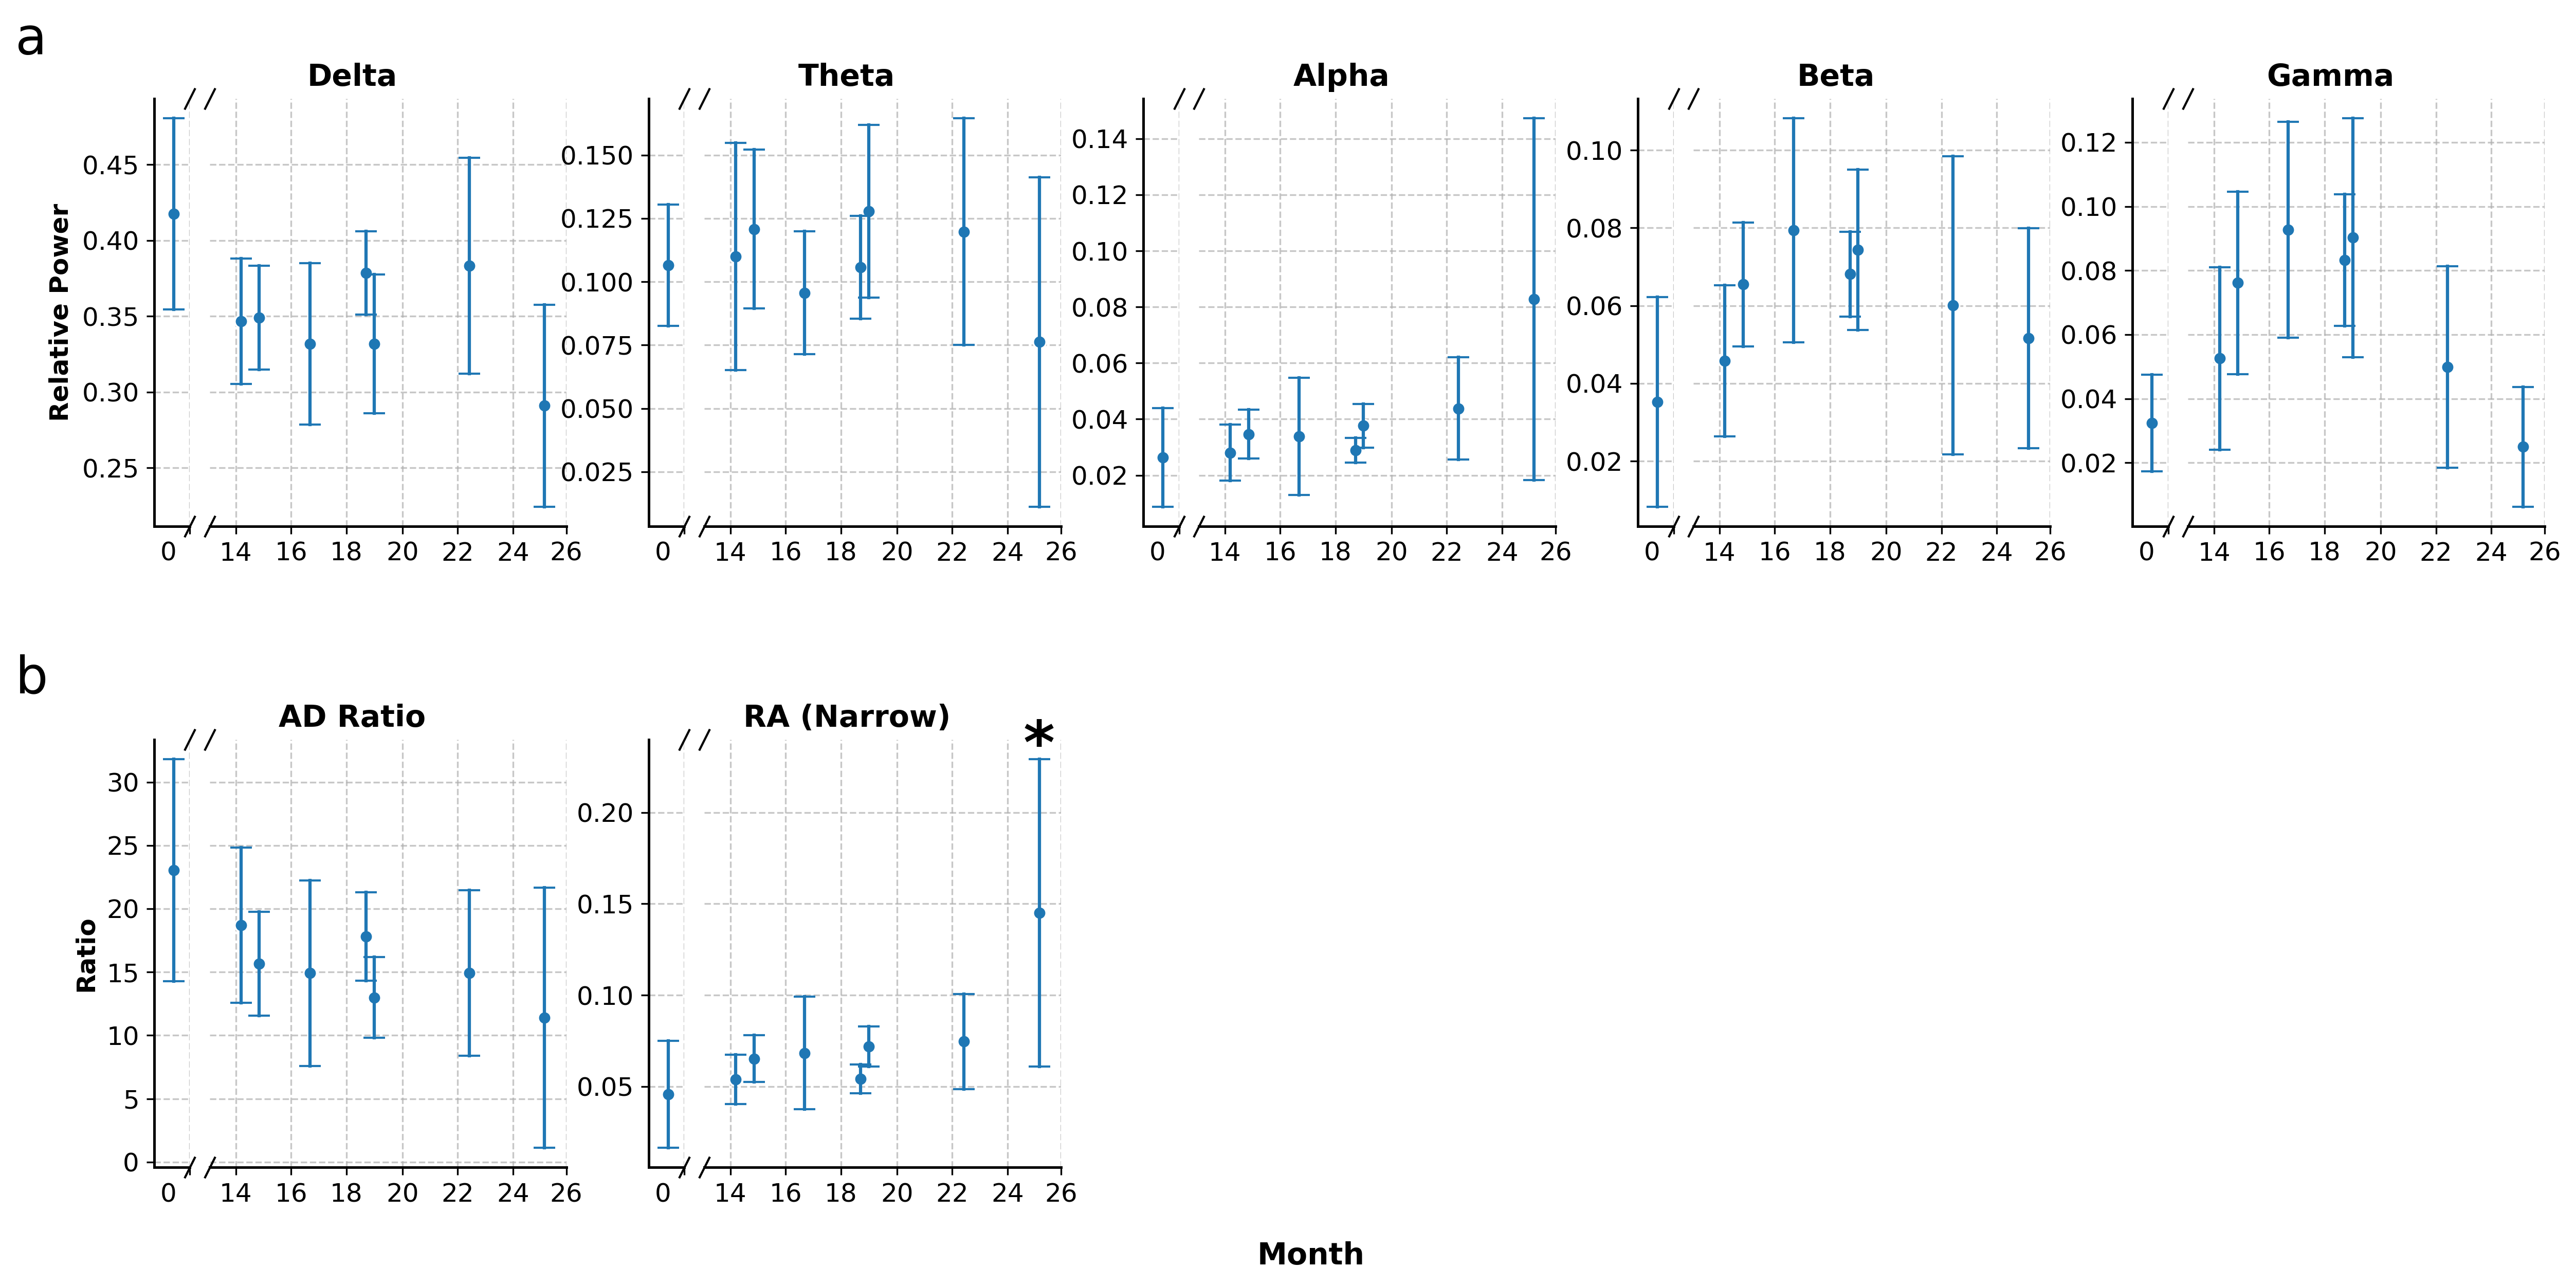

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==========================================
# PUBLICATION QUALITY SETTINGS
# ==========================================
# Force TrueType fonts (Type 42) instead of Type 3 fonts (required by most publishers)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Ensure fonts are embedded
plt.rcParams['font.family'] = 'sans-serif' # or 'Arial', 'Times New Roman', etc.
# ==========================================

# Overall figure setup: 2 rows, 5 columns
fig = plt.figure(figsize=(20, 9))
outer = gridspec.GridSpec(2, 5, wspace=0.2, hspace=0.5)

# Define configurations for Series A (Top) and Series B (Bottom)
plot_configs = [
    {
        'keys': ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'],
        'row': 0,
        'ylabel': 'Relative Power',
        'series_label': 'A',
        'title': 'Power Metrics over time'
    },
    {
        'keys': ['AD Ratio', 'RAV'],
        'row': 1,
        'ylabel': 'Ratio',
        'series_label': 'B',
        'title': 'AD Ratio and RA'
    }
]

# Shared slant line properties for the broken axis effect
d = 2.  
slash_kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10, 
                    linestyle="none", color='k', mec='k', mew=1, clip_on=False)

for config in plot_configs:
    keys = config['keys']
    row_idx = config['row']
    
    for i, key in enumerate(keys):
        # Skip if key doesn't exist in your dictionary
        if key not in df_dict:
            continue
            
        # Prepare data
        data = df_dict[key].stack().reset_index()
        data.columns = ['Date', '', 'Power']
        data['Date'] = pd.to_datetime(data['Date'], format='%m-%d-%Y')
        
        # Create inner broken-axis layout inside the designated outer cell
        inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[row_idx, i], 
                                                 width_ratios=(1, 10), wspace=0.1)
        
        for j in range(2):
            ax1 = plt.Subplot(fig, inner[j])

            # Lineplot
            sns.lineplot(
                ax=ax1, x='Date', y='Power', data=data, 
                errorbar='sd', err_style='bars', err_kws={'capsize': 5, 'elinewidth': 1.5}, 
                marker='o', markersize=6, color='tab:blue', linestyle='none'
            )

            # Standard X-Axis formatting
            fmt_half_year1 = mdates.MonthLocator(interval=2)
            ax1.xaxis.set_major_locator(fmt_half_year1)
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax1.format_xdata = mdates.DateFormatter('%Y-%m')
            ax1.grid(True, linestyle='--', alpha=0.7) # Softened gridlines for cleaner look

            if j == 0:
                # --- LEFT SIDE OF BROKEN AXIS ---
                ax1.spines['right'].set_visible(False)
                ax1.spines['top'].set_visible(False) # Removed top spine for cleaner look
                ax1.xaxis.tick_bottom()
                ax1.set_xlim(np.datetime64('2023-01'), np.datetime64('2023-02'))
                ax1.set_xticklabels(['0'])

                # Apply offset transform to x ticklabels
                dx, dy = -10/72., 0/72. 
                offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
                for label in ax1.xaxis.get_majorticklabels():
                    label.set_transform(label.get_transform() + offset)

                ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **slash_kwargs)
                
                # Set y-label only for the first column
                if i == 0:
                    ax1.set_ylabel(config['ylabel'], fontsize=12, fontweight='bold')
                else:
                    ax1.set_ylabel('')
                    
            else:
                # --- RIGHT SIDE OF BROKEN AXIS ---
                ax1.spines['left'].set_visible(False)
                ax1.spines['top'].set_visible(False) # Removed top spine for cleaner look
                ax1.yaxis.tick_right()
                ax1.tick_params(labelright=False, right=False) # Removed right ticks entirely
                ax1.set_xlim(np.datetime64('2024-02'), np.datetime64('2025-03'))
                ax1.set_xticklabels(['14', '16', '18', '20', '22', '24','26'])

                ax1.plot([0, 0], [0, 1], transform=ax1.transAxes, **slash_kwargs)
                ax1.set_ylabel('')
                ax1.set_title(f'{key}', fontsize=14, fontweight='bold', x=0.4)

                # Add asterisk specific to RAV
                if key == 'RAV':
                    ax1.set_title('RA (Narrow)', fontsize=14, fontweight='bold', x=0.4)
                    target_date = pd.to_datetime('2025-02-05')
                    if target_date in data['Date'].values:
                        y_max = data[data['Date'] == target_date]['Power'].max()
                        ax1.annotate('*', xy=(target_date, y_max - 0.05), xytext=(target_date, y_max - 0.05),
                                     ha='center', va='bottom', fontsize=28, color='black', fontweight='bold')
                
            ax1.set_xlabel('')
            fig.add_subplot(ax1)

# Add overarching labels and text
fig.text(s='Month', x=0.5, y=0.04, fontsize=14, fontweight='bold', ha='center')

# Add 'A' and 'B' labels to the top left of their respective rows (standard journal format)
fig.text(0.08, 0.94, 'a', fontsize=24, fontweight='normal', va='top', fontfamily='sans-serif')
fig.text(0.08, 0.48, 'b', fontsize=24, fontweight='normal', va='top', fontfamily='sans-serif')

# Avoid suptitle in standard publications (they usually use figure captions instead) 
# but kept here if you need it for a poster/presentation:
# fig.suptitle('Power Metrics and Ratios Over Time', fontsize=20, y=0.98)

# Layout adjustments
fig.tight_layout(rect=[0, 0.06, 1, 0.95]) 

# ==========================================
# PUBLICATION QUALITY SAVE
# ==========================================
fig.savefig(
    'fig4_boxplot.pdf', 
    format='pdf',
    bbox_inches='tight', 
    dpi=600,                # 600 DPI is standard for high-quality scientific figures
    facecolor='white',      # Ensures no transparent background issues
    edgecolor='none'
)
# ==========================================

plt.show()

C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\1036093384.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(new_tick_labels)
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\1036093384.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(new_tick_labels)
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\1036093384.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(new_tick_labels)
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\1036093384.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(new_tick_labels)
C:\Users\hoame\AppData\Local\Temp\ipykernel_49392\10360933

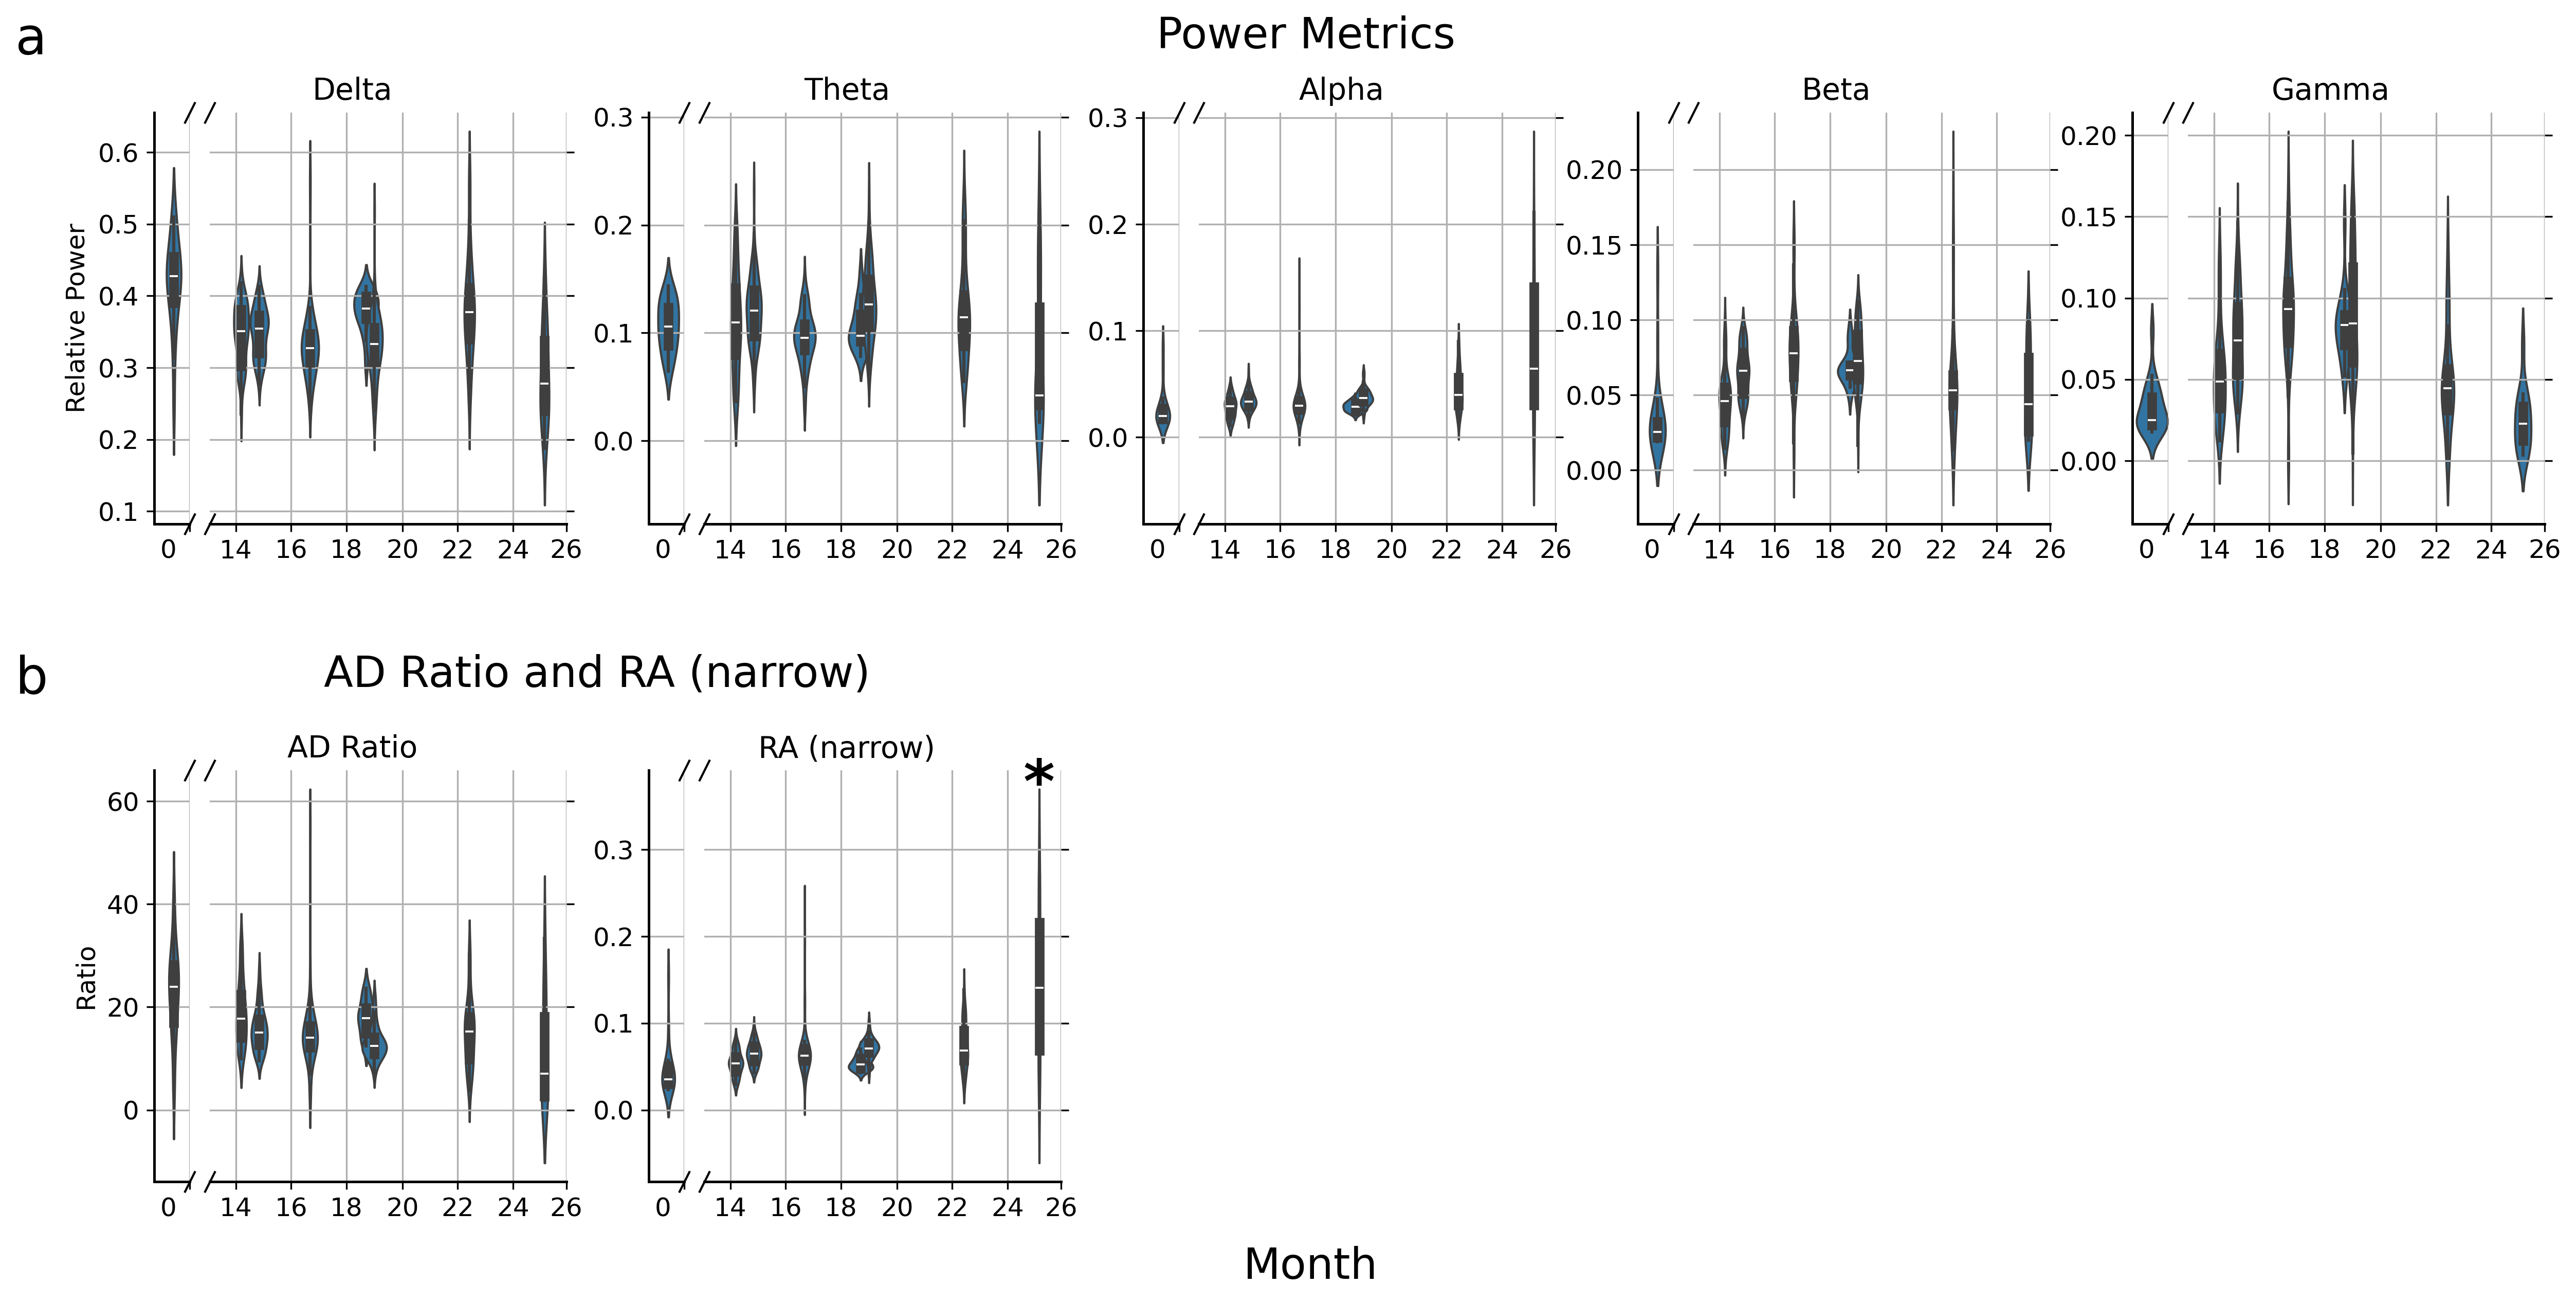

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==========================================
# PUBLICATION QUALITY SETTINGS
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif' 
# ==========================================

# Overall figure setup: 2 rows, 5 columns
fig = plt.figure(figsize=(20, 9))
# Increased hspace to ensure titles/labels don't overlap between rows
outer = gridspec.GridSpec(2, 5, wspace=0.2, hspace=0.6)

# Define configurations for Series A (Top) and Series B (Bottom)
plot_configs = [
    {
        'keys': ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'],
        'row': 0,
        'ylabel': 'Relative Power',
    },
    {
        'keys': ['AD Ratio', 'RAV'],
        'row': 1,
        'ylabel': 'Ratio',
    }
]

# Shared slant line properties for the broken axis effect
d = 2.  
slash_kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10, 
                    linestyle="none", color='k', mec='k', mew=1, clip_on=False)

for config in plot_configs:
    keys = config['keys']
    row_idx = config['row']
    
    for i, key in enumerate(keys):
        # Skip if key doesn't exist in your dictionary
        if key not in df_dict:
            continue
            
        # Prepare data
        data = df_dict[key].stack().reset_index()
        data.columns = ['Date', '', 'Power']
        data['Date'] = pd.to_datetime(data['Date'], format='%m-%d-%Y')
        
        # Create inner broken-axis layout inside the designated outer cell
        inner = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[row_idx, i], 
                                                 width_ratios=(1, 10), wspace=0.1)
        
        for j in range(2):
            ax1 = plt.Subplot(fig, inner[j])

            # --- VIOLIN PLOT ---
            sns.violinplot(
                ax=ax1, x='Date', y='Power', data=data, 
                inner='box', linewidth=1, width=3, native_scale=True
            )

            # Standard X-Axis formatting
            fmt_half_year1 = mdates.MonthLocator(interval=2)
            ax1.xaxis.set_major_locator(fmt_half_year1)
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax1.format_xdata = mdates.DateFormatter('%Y-%m')
            ax1.grid(True)

            if j == 0:
                # --- LEFT SIDE OF BROKEN AXIS ---
                ax1.spines.right.set_visible(False)
                ax1.xaxis.tick_bottom()
                datemin1 = np.datetime64('2023-01')
                datemax1 = np.datetime64('2023-02')
                ax1.set_xlim(datemin1, datemax1)

                new_tick_labels = ['0']
                ax1.set_xticklabels(new_tick_labels)

                # Apply offset transform to x ticklabels
                dx, dy = -10/72., 0/72. 
                offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
                for label in ax1.xaxis.get_majorticklabels():
                    label.set_transform(label.get_transform() + offset)

                ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **slash_kwargs)
                
                # Set y-label only for the first column of the row
                if i == 0:
                    ax1.set_ylabel(config['ylabel'], fontsize=12)
                else:
                    ax1.set_ylabel('')
                    
            else:
                # --- RIGHT SIDE OF BROKEN AXIS ---
                ax1.spines.left.set_visible(False)
                ax1.yaxis.tick_right()
                ax1.tick_params(labelright=False)
                datemin2 = np.datetime64('2024-02')
                datemax2 = np.datetime64('2025-03')
                ax1.set_xlim(datemin2, datemax2)

                # Define new tick locations and labels
                new_tick_labels = ['14', '16', '18', '20', '22', '24','26']
                ax1.set_xticklabels(new_tick_labels)

                ax1.plot([0, 0], [0, 1], transform=ax1.transAxes, **slash_kwargs)
                ax1.set_ylabel('')
                
                # Set Title (Applying 'RA (narrow)' override)
                if key == 'RAV':
                    ax1.set_title('RA (narrow)', fontsize=14, x=0.4)
                else:
                    ax1.set_title(f'{key}', fontsize=14, x=0.4)

                # Add asterisk specific to RAV
                if key == 'RAV':
                    target_date = pd.to_datetime('2025-02-05')
                    if target_date in data['Date'].values:
                        y_max = data[data['Date'] == target_date]['Power'].max()
                        ax1.annotate('*', xy=(target_date, y_max + 0.03), xytext=(target_date, y_max + 0.07),
                                     ha='center', va='bottom', fontsize=28, color='black', fontweight='bold')
                
            ax1.set_xlabel('')
            fig.add_subplot(ax1)

# Add overarching bottom label
fig.text(s='Month', x=0.5, y=0.04, fontsize=20, ha='center')

# ==========================================
# PANEL LABELS AND TITLES 
# ==========================================
# Panel A Title
fig.text(0.08, 0.95, 'a', fontsize=24, fontweight='normal', va='top')
fig.text(0.45,  0.95, 'Power Metrics', fontsize=20, va='top')

# Panel B Title
fig.text(0.08, 0.49, 'b', fontsize=24, fontweight='normal', va='top')
fig.text(0.18, 0.49, 'AD Ratio and RA (narrow)', fontsize=20, va='top')
# ==========================================

# Layout adjustments
fig.tight_layout(rect=[0.02, 0.05, 1, 0.93]) 

# Save
fig.savefig('OKM_ED_Fig4.pdf', bbox_inches='tight', dpi=600, facecolor='white', edgecolor='none')
plt.show()